# Clonamos el repositorio con los modelos y herramientas

In [1]:
# !git clone https://github.com/dannasalazar11/Msc_thesis.git

In [2]:
import sys
sys.path.append('/root/msc_myown')


from gmrrnet_adhd.utils import get_segmented_data
#from tensorflow.keras.mixed_precision import set_global_policy
#set_global_policy('mixed_float16')


import tensorflow as tf
import numpy as np
import random
import os

# Establecer semilla
seed = 42

# Semillas para módulos principales
np.random.seed(seed)
random.seed(seed)
tf.random.set_seed(seed)

# Importar base de datos segmentada (Segmentos de 4 seg con translape del 50%, es decir, de 2 seg)

In [3]:
X, y, sbjs = get_segmented_data()
X.shape, y.shape, len(sbjs)

((8162, 19, 512), (8162, 2), 8162)

# Importamos el modelo y definimos los hiperparámetros

In [4]:
import os

import pickle

#with open("/kaggle/input/ieee-tdah-control-database/folds.pkl", "rb") as f:
with open("/root/msc_myown/data/processed/folds.pkl", "rb") as f:
    folds = pickle.load(f)

In [5]:
from pathlib import Path
import sys

# Prefer the project package version of the model definition.
repo_root = Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from TGARNet.models.TGARNet import (
    TGARNet,
    inspect_gaussian_sigmas,
    RenyiMutualInformation,
    NormalizedBinaryCrossentropy,
)

# Backward-compatible alias so the rest of this notebook can stay unchanged.
GMRRNet = TGARNet


In [6]:
# Model definitions moved to TGARNet/models/TGARNet.py
# This cell is intentionally left minimal to avoid shadowing the package implementation.


In [7]:
# Model definitions moved to TGARNet/models/TGARNet.py
# This cell is intentionally left minimal to avoid shadowing the package implementation.


In [8]:
# Model definitions moved to TGARNet/models/TGARNet.py
# This cell is intentionally left minimal to avoid shadowing the package implementation.


In [9]:
# Model definitions moved to TGARNet/models/TGARNet.py
# This cell is intentionally left minimal to avoid shadowing the package implementation.


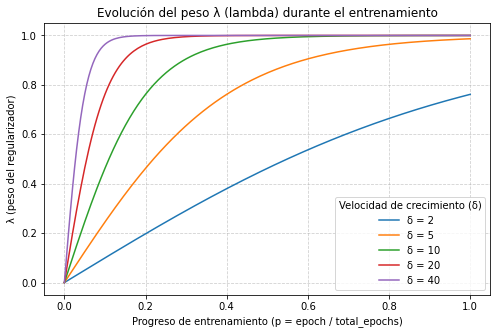

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def get_lambda(p, delta=10):
    """Crecimiento sigmoidal del peso regularizador."""
    return (1 - np.exp(-delta * p)) / (1 + np.exp(-delta * p))

# --- Configuración ---
deltas = [2, 5, 10, 20, 40]  # distintos niveles de crecimiento
p = np.linspace(0, 1, 200)   # progreso normalizado (epoch/total_epochs)

plt.figure(figsize=(8, 5))
for d in deltas:
    λ = get_lambda(p, delta=d)
    plt.plot(p, λ, label=f"δ = {d}")

plt.title("Evolución del peso λ (lambda) durante el entrenamiento")
plt.xlabel("Progreso de entrenamiento (p = epoch / total_epochs)")
plt.ylabel("λ (peso del regularizador)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(title="Velocidad de crecimiento (δ)")
plt.show()

In [11]:
EPOCHS = 150

In [12]:
import numpy as np
import os
import scipy.io
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import OneHotEncoder
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import accuracy_score, cohen_kappa_score, roc_auc_score, precision_score, recall_score
from tensorflow.keras.optimizers import Adam
from copy import deepcopy
from collections import defaultdict
import tensorflow as tf
import random


def train_L24O_cv(model_builder, X, y, sbjs, model_args, compile_args, folds, model_name='', delta=10, seed=42):
    all_fold_metrics = []
    total_histories = []
    models = {}  # <--- aquí se almacenarán todos los modelos entrenados por fold

    for fold, (train_subjects, test_subjects) in enumerate(folds):
        print(f"\n{'-'*60}")
        print(f"Fold {fold+1}/{len(folds)}  |  Test subjects: {test_subjects}")
        print(f"{'-'*60}")

        # --- Índices de entrenamiento y prueba ---
        train_idx = [i for i, sbj in enumerate(sbjs) if sbj in train_subjects]
        test_idx = [i for i, sbj in enumerate(sbjs) if sbj in test_subjects]

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        sbjs_test = [sbjs[i] for i in test_idx]

        # --- Reiniciar contexto de TensorFlow ---
        tf.keras.backend.clear_session()

        # --- Semillas reproducibles ---
        np.random.seed(seed + fold)
        random.seed(seed + fold)
        tf.random.set_seed(seed + fold)

        # --- Construcción del modelo ---
        model = model_builder(**model_args)
        optimizer = Adam(learning_rate=1e-3)
        compile_args_local = deepcopy(compile_args)
        compile_args_local['optimizer'] = optimizer
        model.compile(**compile_args_local)
        num_kernels = model_args["num_kernels"]

        # --- Callbacks ---
        early_stopping = EarlyStopping(
            monitor='val_loss', patience=25, min_delta=1e-4, restore_best_weights=True, verbose=1
        )
        reduce_lr = ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1
        )
        dynamic_schedule = DynamicSchedule(
            total_epochs=150, optimizer=Adam(learning_rate=1e-3), delta=delta
        )

        # --- Entrenamiento ---
        history = model.fit(
            X_train,
            {
                'out_activation': y_train,
                'entropies_out': np.zeros((len(y_train), 4)),
                'kernel_weights_out': np.zeros((len(y_train), num_kernels))
            },
            validation_data=(X_test, {
                'out_activation': y_test,
                'entropies_out': np.zeros((len(y_test), 4)),
                'kernel_weights_out': np.zeros((len(y_test), num_kernels))
            }),
            epochs=100,
            batch_size=16,
            callbacks= [
                # early_stopping, 
                       # reduce_lr, 
                dynamic_schedule],
            verbose=0
        )

        total_histories.append(history)

        # --- Pesos convexos ---
        alpha = model.get_layer("convex_combination").get_weights()[0]
        print("Pesos convexos aprendidos (softmax):", tf.nn.softmax(alpha).numpy())
        print("Suma total:", tf.reduce_sum(tf.nn.softmax(alpha)).numpy())

        # --- Predicciones y métricas ---
        preds = model.predict(X_test)
        y_pred_probs = preds['out_activation']
        y_pred = np.argmax(y_pred_probs, axis=1)
        y_true = np.argmax(y_test, axis=1)

        fold_metrics = {
            'accuracy': accuracy_score(y_true, y_pred),
            'recall': recall_score(y_true, y_pred, average='macro', zero_division=0),
            'precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
            'kappa': cohen_kappa_score(y_true, y_pred),
            'auc': roc_auc_score(y_true, y_pred_probs[:, 1])
        }
        all_fold_metrics.append(fold_metrics)
        print(f"Fold {fold+1} Metrics: {fold_metrics}")

        # --- Guardar modelo de este fold ---
        models[fold] = model  # ✅ aquí se almacena el modelo

        # --- Accuracy por sujeto ---
        subject_correct = defaultdict(list)
        for yt, yp, sbj in zip(y_true, y_pred, sbjs_test):
            subject_correct[sbj].append(int(yt == yp))

        subject_accuracies = {sbj: np.mean(vals) for sbj, vals in subject_correct.items()}
        print("Accuracy promedio por sujeto:")
        for sbj in test_subjects:
            acc_sbj = subject_accuracies.get(sbj, None)
            if acc_sbj is not None:
                print(f"  {sbj}: {acc_sbj:.4f}")

    # --- Promedio global de métricas ---
    mean_metrics = {}
    for key in all_fold_metrics[0].keys():
        vals = [f[key] for f in all_fold_metrics]
        mean_metrics[f'mean_{key}'] = np.mean(vals)
        mean_metrics[f'std_{key}'] = np.std(vals)

    print("\nIndividual Fold Accuracies:")
    for i, f in enumerate(all_fold_metrics):
        print(f"  Fold {i+1}: {f['accuracy']:.4f}")

    return all_fold_metrics, models, total_histories  # ✅ ahora devuelve todos los modelos

In [13]:
from tensorflow.keras.losses import CategoricalCrossentropy, MeanSquaredError
from tensorflow.keras.utils import get_custom_objects

get_custom_objects().update({
    "RenyiMutualInformation": RenyiMutualInformation
})

model_name = 'GMRRNet'
model_args = {
    'num_kernels': 3,
    'nb_classes': 2,
    'Chans': 19,
    'Samples': 512,
    'norm_rate': 0.1,
    'alpha': 2,
    'num_heads': 2,
    'intermediate_dim': 64,
    'kernel_sigmas': [5.0, 2.5, 1.25]
}
compile_args = {
    'optimizer': Adam(learning_rate=1e-3),
    'loss': {
        'out_activation': NormalizedBinaryCrossentropy(name="NormalizedBinaryCrossentropy"),
        'entropies_out': RenyiMutualInformation(C=19.0, name='MutualInfo'),
        'kernel_weights_out': 'mean_squared_error'
    },
    'loss_weights': {
        'out_activation': 0.5,  # Inicial
        'entropies_out': 0.5,
        'kernel_weights_out': 0.0
    },
    'metrics': {'out_activation': ['binary_accuracy', tf.keras.metrics.AUC(name="AUC")]}
    }

import tensorflow as tf
import numpy as np

class DynamicSchedule(tf.keras.callbacks.Callback):
    def __init__(self, total_epochs, optimizer, eta_0=1e-3, alpha=10, beta=0.75, delta=10):
        super().__init__()
        self.total_epochs = total_epochs
        self.eta_0 = eta_0
        self.alpha = alpha
        self.beta = beta
        self.delta = delta
        self.optimizer = optimizer
        self.lambda_val = 0.0

    def get_eta(self, epoch):
        p = epoch / self.total_epochs
        return self.eta_0 * (1 + self.alpha * p) ** (-self.beta)

    def get_lambda(self, epoch):
        p = epoch / self.total_epochs
        return 2 * (1 - np.exp(-self.delta * p)) / (1 + np.exp(-self.delta * p))

    def on_epoch_begin(self, epoch, logs=None):
        new_lr = self.get_eta(epoch)
        self.lambda_val = self.get_lambda(epoch)

        # ✅ Ajustar learning rate correctamente
        if hasattr(self.optimizer.learning_rate, "assign"):
            self.optimizer.learning_rate.assign(new_lr)
        else:
            tf.keras.backend.set_value(self.optimizer.learning_rate, new_lr)

        # ✅ Actualizar dinámicamente los pesos de pérdida SIN recompilar
        if hasattr(self.model, "loss_weights") and isinstance(self.model.loss_weights, dict):
            self.model.loss_weights["out_activation"] = 1.0
            self.model.loss_weights["entropies_out"] = self.lambda_val

        print(f"[Epoch {epoch+1}] LR={float(new_lr):.6f} | λ={self.lambda_val:.3f}")


2026-04-04 15:04:05.799341: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-04 15:04:06.408892: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1532] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22129 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:81:00.0, compute capability: 8.9


In [14]:
# results = {}

# for i in range(1):
#     result, models, total_histories = train_L24O_cv(GMRRNet, X, y, sbjs, model_args, compile_args, folds, model_name, delta=20)
#     results[i]=result

results = {}
repeat_seeds = [42, 43, 44]

for repeat_id, repeat_seed in enumerate(repeat_seeds):
    print(f"\n{'='*70}")
    print(f"Repeat {repeat_id + 1}/{len(repeat_seeds)} | seed={repeat_seed}")
    print(f"{'='*70}")

    result, models, total_histories = train_L24O_cv(
        GMRRNet,
        X,
        y,
        sbjs,
        model_args,
        compile_args,
        folds,
        model_name,
        delta=20,
        seed=repeat_seed
    )

    results[repeat_id] = {
        "repeat_seed": repeat_seed,
        "metrics": result
    }



Repeat 1/3 | seed=42

------------------------------------------------------------
Fold 1/5  |  Test subjects: ['v41p', 'v42p', 'v54p', 'v57p', 'v58p', 'v60p', 'v115', 'v123', 'v138', 'v143', 'v299', 'v305', 'v10p', 'v21p', 'v22p', 'v27p', 'v31p', 'v34p', 'v213', 'v238', 'v244', 'v246', 'v284', 'v288']
------------------------------------------------------------
[Epoch 1] LR=0.001000 | λ=0.000


2026-04-04 15:04:12.943680: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8101
2026-04-04 15:04:13.617373: I tensorflow/stream_executor/cuda/cuda_blas.cc:1786] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.
2026-04-04 15:04:14.508056: W tensorflow/stream_executor/gpu/asm_compiler.cc:230] Falling back to the CUDA driver for PTX compilation; ptxas does not support CC 8.9
2026-04-04 15:04:14.508108: W tensorflow/stream_executor/gpu/asm_compiler.cc:233] Used ptxas at ptxas
2026-04-04 15:04:14.508300: W tensorflow/stream_executor/gpu/redzone_allocator.cc:314] UNIMPLEMENTED: ptxas ptxas too old. Falling back to the driver to compile.
Relying on driver to perform ptx compilation. 
Modify $PATH to customize ptxas location.
This message will be only logged once.


[Epoch 2] LR=0.000953 | λ=0.133
[Epoch 3] LR=0.000910 | λ=0.265
[Epoch 4] LR=0.000872 | λ=0.395
[Epoch 5] LR=0.000838 | λ=0.521
[Epoch 6] LR=0.000806 | λ=0.643
[Epoch 7] LR=0.000777 | λ=0.760
[Epoch 8] LR=0.000750 | λ=0.871
[Epoch 9] LR=0.000726 | λ=0.976
[Epoch 10] LR=0.000703 | λ=1.074
[Epoch 11] LR=0.000682 | λ=1.166
[Epoch 12] LR=0.000662 | λ=1.250
[Epoch 13] LR=0.000643 | λ=1.328
[Epoch 14] LR=0.000626 | λ=1.399
[Epoch 15] LR=0.000610 | λ=1.464
[Epoch 16] LR=0.000595 | λ=1.523
[Epoch 17] LR=0.000580 | λ=1.576
[Epoch 18] LR=0.000567 | λ=1.624
[Epoch 19] LR=0.000554 | λ=1.667
[Epoch 20] LR=0.000541 | λ=1.706
[Epoch 21] LR=0.000530 | λ=1.740
[Epoch 22] LR=0.000519 | λ=1.771
[Epoch 23] LR=0.000508 | λ=1.798
[Epoch 24] LR=0.000498 | λ=1.822
[Epoch 25] LR=0.000488 | λ=1.843
[Epoch 26] LR=0.000479 | λ=1.862
[Epoch 27] LR=0.000470 | λ=1.879
[Epoch 28] LR=0.000462 | λ=1.894
[Epoch 29] LR=0.000454 | λ=1.907
[Epoch 30] LR=0.000446 | λ=1.918
[Epoch 31] LR=0.000439 | λ=1.928
[Epoch 32] LR=0.00

In [15]:
results

{0: {'repeat_seed': 42,
  'metrics': [{'accuracy': 0.777988614800759,
    'recall': 0.7802359241568968,
    'precision': 0.779024355094394,
    'kappa': 0.5567449049279322,
    'auc': 0.894840867789196},
   {'accuracy': 0.753968253968254,
    'recall': 0.7680668327846845,
    'precision': 0.8064861512738635,
    'kappa': 0.5201760213761011,
    'auc': 0.9019286871232565},
   {'accuracy': 0.7777777777777778,
    'recall': 0.7551268017636652,
    'precision': 0.8060518625975444,
    'kappa': 0.5304818630800814,
    'auc': 0.8766034380003973},
   {'accuracy': 0.8344414893617021,
    'recall': 0.8413553323084624,
    'precision': 0.8390070921985815,
    'kappa': 0.6710156895127993,
    'auc': 0.8682993099996426},
   {'accuracy': 0.6804489072652097,
    'recall': 0.7067026723454721,
    'precision': 0.7228337200547045,
    'kappa': 0.3877451842186358,
    'auc': 0.8586826995991768}]},
 1: {'repeat_seed': 43,
  'metrics': [{'accuracy': 0.8545224541429475,
    'recall': 0.8565687267814928,
  

In [17]:
print(history.history.keys())



dict_keys(['loss', 'concatenated_entropies_loss', 'convex_combination_loss', 'out_activation_loss', 'out_activation_binary_accuracy', 'out_activation_AUC', 'val_loss', 'val_concatenated_entropies_loss', 'val_convex_combination_loss', 'val_out_activation_loss', 'val_out_activation_binary_accuracy', 'val_out_activation_AUC'])


In [ ]:
import matplotlib.pyplot as plt

for history in total_histories:
    # Extrae las pérdidas del history
    loss_total = history.history['loss']
    loss_bce = history.history['out_activation_loss']
    #loss_entropy = history.history['entropies_out_loss']
    loss_entropy = history.history['concatenated_entropies_loss']

    val_loss_total = history.history['val_loss']
    val_loss_bce = history.history['val_out_activation_loss']
    #val_loss_entropy = history.history['val_entropies_out_loss']
    val_loss_entropy = history.history['val_concatenated_entropies_loss']

    # --- Gráfico combinado ---
    plt.figure(figsize=(10,6))
    
    # Entrenamiento
    plt.plot(loss_bce, label='Train BCE', color='tab:blue')
    plt.plot(loss_entropy, label='Train Renyi MI', color='tab:orange')
    plt.plot(loss_total, label='Train Total', linestyle='-', color='black')
    
    # Validación
    plt.plot(val_loss_bce, label='Val BCE', color='tab:blue', linestyle=':')
    plt.plot(val_loss_entropy, label='Val Renyi MI', color='tab:orange', linestyle=':')
    plt.plot(val_loss_total, label='Val Total', linestyle='--', color='gray')
    
    plt.title('损失曲线（训练与验证）')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

KeyError: 'val_entropies_out_loss'